In [ ]:
# exr read test

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1" 
os.environ["OPENCV_IMGCODECS_USE_OPENEXR"] = "1"

def read_exr(path):
    bgr = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb.astype(np.float32)

exr_path = '/data3/lihaochen/datasets/synthetic_human_pp/jody/relight/olat0004-0019/rendering/000000_12_rgb.exr'

exr = read_exr(exr_path)

plt.imshow(exr)

In [ ]:
# mask convertion test

normal = '/data3/lihaochen/datasets/synthetic_human_pp/jody/relight/olat0004-0019/normal/000000_12_normals.png'
normal = cv2.imread(normal, cv2.IMREAD_UNCHANGED)
mask = np.all(normal == [191,191,191], axis=-1).astype(np.uint8)
mask = 1 - mask
mask = np.expand_dims(mask, axis=-1)

plt.imshow(mask*exr)

In [ ]:
def get_(cams, index):
    return cams['K'][index], cams['R'][index], cams['T'][index]

def calculate_phi_theta_via_arccos(R):
    """
    根据旋转矩阵 R 使用 arccos 计算旋转角度 phi 和 theta.
    
    参数:
    - R: 3x3 的旋转矩阵

    返回:
    - phi: 绕 z 轴的旋转角度(偏航角 Yaw)
    - theta: 绕 y 轴的旋转角度(俯仰角 Pitch)
    """

    # 计算 theta (绕 y 轴) 的旋转角度
    theta = np.arccos(R[2, 2])

    # 计算 phi (绕 z 轴) 的旋转角度
    phi = np.arctan2(R[2, 1], R[2, 0])

    # 转换为度数
    theta = (theta / np.pi) * 2 - 1
    phi = -phi / np.pi

    return phi, theta

dataset_root = '/data3/lihaochen/datasets/synthetic_human_pp/'
person = os.listdir(dataset_root)
person = [p for p in person if p != 'lighting' and os.path.isdir(os.path.join(dataset_root, p))]
person.sort()

dataset = []
for p in person:
    caption = np.load(os.path.join(dataset_root, f'{p}_prompt.npy'), allow_pickle=True).item()
    relight = os.path.join(dataset_root, p, 'relight')
    relight = os.listdir(relight)
    relight = [r for r in relight if os.path.isdir(os.path.join(dataset_root, p, 'relight', r))]
    relight.sort()
    angle = os.path.join(dataset_root, p, 'relight', relight[0], 'rendering')
    angle = os.listdir(angle)
    angle = [a for a in angle if os.path.isfile(os.path.join(dataset_root, p, 'relight', relight[0], 'rendering', a))]
    angle.sort()
    mask = os.path.join(dataset_root, p, 'relight', relight[0], 'normal')
    mask = os.listdir(mask)
    mask_f = [m for m in mask if os.path.isfile(os.path.join(dataset_root, p, 'relight', relight[0], 'normal', m))]
    mask_f.sort()
    
    cams = np.load(f'/data3/lihaochen/datasets/synthetic_human_pp/{p}/annots.npy', allow_pickle=True).ravel()[0]

    for a, m in zip(angle, mask_f):
        for r1 in relight:
            for r2 in relight:
                if r1 == r2:
                    continue
                source = os.path.join(dataset_root, p, 'relight', r1, 'rendering', a)
                target = os.path.join(dataset_root, p, 'relight', r2, 'rendering', a)
                mask = os.path.join(dataset_root, p, 'relight', r1, 'normal', m)
                depth = os.path.join(dataset_root, p, 'relight', r1, 'depth', a[:-8] + '_depth.npy')
                lighting = os.path.join(dataset_root, 'lighting', '16x32', r2+'.hdr')
                K, R, T = get_(cams['cams'], int(a[:-8].split('_')[-1]))
                phi, theta = calculate_phi_theta_via_arccos(R)
                # a[:-8] no use for now
                dataset.append([p, phi, mask, source, target, depth, caption[r1][a], lighting])

print(len(dataset))
print(dataset[0])
    

In [ ]:
import datasets

# convert dataset to dict
dict_dataset = {
    'person': [r[0] for r in dataset],
    # 'angle': [r[1] for r in dataset],
    'phi': [r[1] for r in dataset],
    'mask': [r[2] for r in dataset],
    'source': [r[3] for r in dataset],
    'target': [r[4] for r in dataset],
    'depth': [r[5] for r in dataset],
    'caption': [r[6] for r in dataset],
    'lighting': [r[7] for r in dataset],
}

ds = datasets.Dataset.from_dict(dict_dataset)

ds.to_parquet('./stage1.parquet')

In [2]:
# dataset read test
import os
from datasets import load_dataset
from torchvision import transforms
from torchvision.transforms import v2

ds = load_dataset('/data/lihaochen/projects/EzRelight', data_files='stage1.parquet')

os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1" 
os.environ["OPENCV_IMGCODECS_USE_OPENEXR"] = "1"

t = v2.Compose([
    v2.ToTensor(),
    v2.Resize(size=512, max_size=1024, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Pad([0, 256], fill=0.25, padding_mode='constant'),
])

def preprocess_train(examples):
    source = [cv2.imread(source, cv2.IMREAD_UNCHANGED) for source in examples['source']]
    source = [cv2.cvtColor(s, cv2.COLOR_BGR2RGB) for s in source]

    target = [cv2.imread(target, cv2.IMREAD_UNCHANGED) for target in examples['target']]
    target = [cv2.cvtColor(t, cv2.COLOR_BGR2RGB) for t in target]

    mask = [cv2.imread(mask, cv2.IMREAD_UNCHANGED) for mask in examples['mask']]
    mask = [1 - np.all(m == [191,191,191], axis=-1).astype(np.uint8) for m in mask]
    mask = [np.expand_dims(m, axis=-1) for m in mask]

    depth = [np.load(depth) for depth in examples['depth']]

    lighting = [cv2.imread(lighting, cv2.IMREAD_UNCHANGED) for lighting in examples['lighting']]
    lighting = [cv2.cvtColor(l, cv2.COLOR_BGR2RGB) for l in lighting]
    lighting = [np.roll(l, -int(l.shape[1] * phi / 2), 1) for l, phi in zip(lighting, examples['phi'])]
    lighting = [t(l) for l in lighting]

    examples['source'] = source
    examples['target'] = target
    examples['mask'] = mask
    examples['depth'] = depth
    examples['lighting'] = lighting

    return examples

ds_train = ds['train']
# ds_train = ds_train.with_transform(preprocess_train)
# print(ds_train[0]['phi'].dtype)

# img = ds_train[4]['lighting'].permute(1, 2, 0).numpy()
# plt.imshow(img)


/data/lihaochen/anaconda3/envs/iclight/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Repo card metadata block was not found. Setting CardData to empty.
/data/lihaochen/anaconda3/envs/iclight/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.1777834e-06..1.0240161].


(1024, 2048, 3)


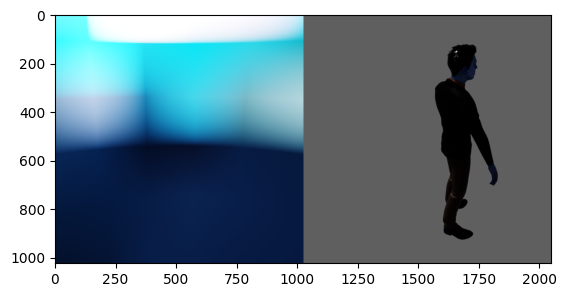

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_transforms = v2.Compose(
    [
        v2.Resize(1024, interpolation=v2.InterpolationMode.BILINEAR),
        v2.CenterCrop(1024),
        v2.ToTensor(),
        v2.Normalize([0.5], [0.5]),
    ]
)

conditioning_image_transforms = v2.Compose(
    [
        v2.Resize(1024, interpolation=v2.InterpolationMode.BILINEAR),
        v2.CenterCrop(1024),
        v2.ToTensor(),
    ]
)

bg_image_transforms = v2.Compose(
    [
        v2.ToTensor(),
        v2.Resize(size=1024 // 2, max_size=1024, interpolation=v2.InterpolationMode.BILINEAR),
        v2.Pad([0, 256], fill=0.25, padding_mode='constant'),
    ]
)

def preprocess_train(examples):
    source = [cv2.imread(source, cv2.IMREAD_UNCHANGED) for source in examples['source']]
    source = [cv2.cvtColor(s, cv2.COLOR_BGR2RGB) for s in source]
    source = [conditioning_image_transforms(s) for s in source]

    target = [cv2.imread(target, cv2.IMREAD_UNCHANGED) for target in examples['target']]
    target = [cv2.cvtColor(t, cv2.COLOR_BGR2RGB) for t in target]
    target = [image_transforms(t) for t in target]

    mask = [cv2.imread(mask, cv2.IMREAD_UNCHANGED) for mask in examples['mask']]
    mask = [1 - np.all(m == [191,191,191], axis=-1).astype(np.uint8) for m in mask]
    mask = [np.expand_dims(m, axis=-1) for m in mask]
    mask = [conditioning_image_transforms(m) for m in mask]

    depth = [np.load(depth) for depth in examples['depth']]
    depth = [np.expand_dims(d, axis=-1) for d in depth]
    depth = [conditioning_image_transforms(d) for d in depth]

    lighting = [cv2.imread(lighting, cv2.IMREAD_UNCHANGED) for lighting in examples['lighting']]
    lighting = [cv2.cvtColor(l, cv2.COLOR_BGR2RGB) for l in lighting]
    lighting = [np.roll(l, -int(l.shape[1] * phi / 2), 1) for l, phi in zip(lighting, examples['phi'])]
    lighting = [bg_image_transforms(l) for l in lighting]

    phi = [torch.tensor(phi) for phi in examples['phi']]

    examples['source'] = source
    examples['target'] = target
    examples['mask'] = mask
    examples['depth'] = depth
    examples['lighting'] = lighting
    # examples['phi'] = phi
    return examples

# dataset = dataset.remove_columns(["person"])

ds_train = ds_train.with_transform(preprocess_train)

# img = ds_train[4]['lighting'].permute(1, 2, 0).numpy()
# plt.imshow(img)


def collate_fn(examples):
    source = torch.stack([example["source"] for example in examples])
    source = source.to(memory_format=torch.contiguous_format).float()

    target = torch.stack([example["target"] for example in examples])
    target = target.to(memory_format=torch.contiguous_format).float()

    mask = torch.stack([example["mask"] for example in examples])
    mask = mask.to(memory_format=torch.contiguous_format).float()

    depth = torch.stack([example["depth"] for example in examples])
    depth = depth.to(memory_format=torch.contiguous_format).float()

    lighting = torch.stack([example["lighting"] for example in examples])
    lighting = lighting.to(memory_format=torch.contiguous_format).float()

    return {
        "source": source,
        "target": target,
        "mask": mask,
        "depth": depth,
        "lighting": lighting,
    }

train_dataloader = torch.utils.data.DataLoader(
    ds_train,
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=2,
    num_workers=1,
)

def ACESToneMapping(color, adapted_lum):
    A = 2.51
    B = 0.03
    C = 2.43
    D = 0.59
    E = 0.14

    color *= adapted_lum
    return (color * (A * color + B)) / (color * (C * color + D) + E)

for step, batch in enumerate(train_dataloader):
    if step > 0:
        break
    formatted_images = []
    validation_image = batch["source"]
    for img in validation_image:
        formatted_images.append(np.asarray(ACESToneMapping(img, 1.0).permute(1, 2, 0).cpu()))
    formatted_images = np.concatenate(formatted_images, 1)
    formatted_images = cv2.cvtColor(formatted_images, cv2.COLOR_BGR2RGB)
    cv2.imwrite('test1.png', formatted_images * 255)
    plt.imshow(formatted_images)

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
i = 20

def ACESToneMapping(color, adapted_lum):
    A = 2.51
    B = 0.03
    C = 2.43
    D = 0.59
    E = 0.14

    color *= adapted_lum
    return (color * (A * color + B)) / (color * (C * color + D) + E)

plt.imshow(ACESToneMapping(ds_train[i]['source'], 1.0))
print(ds['train'][i]['depth'].shape)